In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
np.random.seed(42)
n = 1200
x = np.random.uniform(-10 , 20 , n)
beta0_true = 5.0
beta1_true = 2.5
y_true = beta0_true + beta1_true * x
sigma = 0.8 + 0.18 * (x + 10)
y = y_true + np.random.normal(0 , sigma)
k = 45
x_out = np.random.uniform(11 , 20 , k)
y_out = beta0_true + beta1_true * x_out + np.random.normal(55 , 20 , k)
X_all = np.concatenate([x , x_out])
Y_all = np.concatenate([y , y_out])
is_outlier = np.zeros_like(X_all , dtype = bool)
is_outlier[-k : ] = True
is_inlier = ~ is_outlier
sigma_all = np.concatenate([sigma , np.full(k , 20.0)])
weights = 1 / (sigma_all ** 2)
X_design = sm.add_constant(X_all)

In [3]:
ols = sm.OLS(Y_all , X_design).fit()
wls = sm.WLS(Y_all , X_design , weights = weights).fit()
lad = sm.QuantReg(Y_all , X_design).fit(q = 0.5)
yhat_ols = ols.predict(X_design)
yhat_wls = wls.predict(X_design)
yhat_lad = lad.predict(X_design)

In [4]:
def rmse(y , yhat):
    return np.sqrt(np.mean((y - yhat) ** 2))
def weighted_rmse(y , yhat , w):
    return np.sqrt(np.sum(w * (y - yhat) ** 2) / np.sum(w))
def median_abs_error(y , yhat):
    return np.median(np.abs(y - yhat))

In [5]:
results = pd.DataFrame({
    "Model": ["OLS" , "WLS" , "LAD"] ,
    "Slope": [ols.params[1] , wls.params[1] , lad.params[1]] ,
    "Intercept": [ols.params[0] , wls.params[0] , lad.params[0]] ,
    "Inlier RMSE": [
        rmse(Y_all[is_inlier] , yhat_ols[is_inlier]) ,
        rmse(Y_all[is_inlier] , yhat_wls[is_inlier]) ,
        rmse(Y_all[is_inlier] , yhat_lad[is_inlier]) ,
    ] , "Weighted RMSE": [
        weighted_rmse(Y_all , yhat_ols , weights) ,
        weighted_rmse(Y_all , yhat_wls , weights) ,
        weighted_rmse(Y_all , yhat_lad , weights) ,
    ] , "Median Abs Error": [median_abs_error(Y_all , yhat_ols) ,
        median_abs_error(Y_all , yhat_wls) , median_abs_error(Y_all , yhat_lad) ,
    ]
})
results["Best Use"] = ["Baseline only" , "Unequal variance" , "Outlier robustness"]
print(results.round(3).to_string(index = False))

Model  Slope  Intercept  Inlier RMSE  Weighted RMSE  Median Abs Error           Best Use
  OLS  2.755      5.683        4.718          3.012             2.563      Baseline only
  WLS  2.509      5.190        3.784          2.486             2.002   Unequal variance
  LAD  2.520      5.209        3.787          2.487             1.991 Outlier robustness


<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Week 5 Summary: Same Data, Different Regression Flavors')

Text(0.5, 0, 'X')

Text(0, 0.5, 'y')

Text(0.02, 0.98, 'OLS gets pulled most\nWLS handles unequal variance\nLAD resists outliers best')

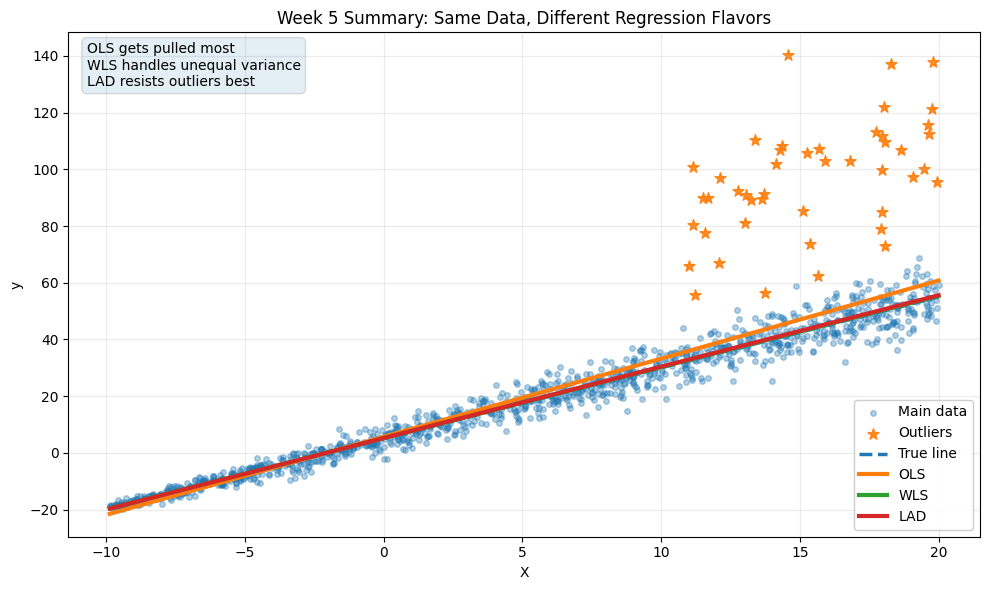

In [6]:
xg = np.linspace(X_all.min() , X_all.max() , 400)
Xg = sm.add_constant(xg)
plt.figure(figsize = (10 , 6))
plt.scatter(X_all[is_inlier] , Y_all[is_inlier] , s = 16 , alpha = 0.35 , label = "Main data")
plt.scatter(X_all[is_outlier] , Y_all[is_outlier] , s = 70 , marker = "*" , alpha = 0.9 , label = "Outliers")
plt.plot(xg , beta0_true + beta1_true * xg , linestyle = "--" , linewidth = 2.5 , label = "True line")
plt.plot(xg , ols.predict(Xg) , linewidth = 3 , label = "OLS")
plt.plot(xg , wls.predict(Xg) , linewidth = 3 , label = "WLS")
plt.plot(xg , lad.predict(Xg) , linewidth = 3 , label = "LAD")
plt.title("Week 5 Summary: Same Data, Different Regression Flavors")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(alpha = 0.25)
note = (
    "OLS gets pulled most\n"
    "WLS handles unequal variance\n"
    "LAD resists outliers best"
)
plt.text(
    0.02 , 0.98 , note , transform = plt.gca().transAxes ,
    va = "top" , bbox = dict(boxstyle = "round , pad = 0.35" , alpha = 0.12)
)
plt.legend(loc = "lower right" , framealpha = 0.95)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Practical Error Comparison')

Text(0, 0.5, 'Error')

(array([0, 1, 2]), [Text(0, 0, 'OLS'), Text(1, 0, 'WLS'), Text(2, 0, 'LAD')])

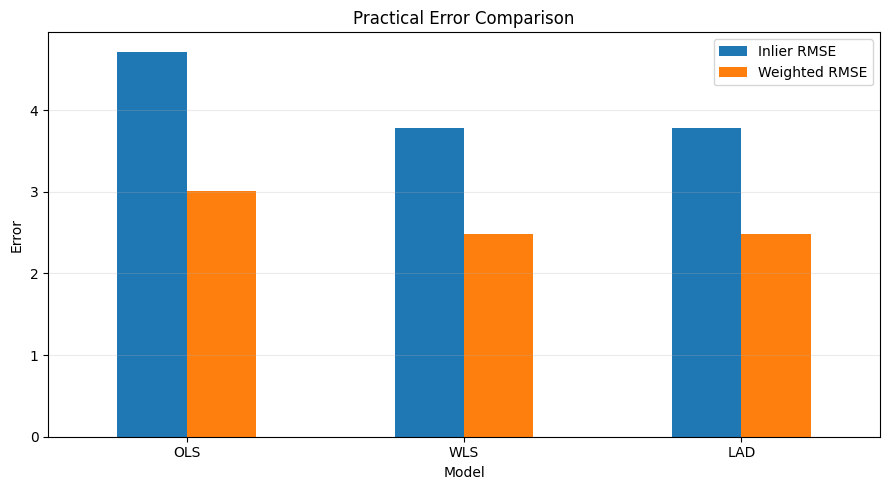

In [7]:
metric_df = results.set_index("Model")[["Inlier RMSE" , "Weighted RMSE"]]
ax = metric_df.plot(kind = "bar" , figsize = (9 , 5))
plt.title("Practical Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation = 0)
plt.grid(axis = "y" , alpha = 0.25)
plt.tight_layout()
plt.show()

In [8]:
decision_guide = pd.DataFrame({
    "Data situation": ["Clean, stable variance" , "Variance changes across X" ,
        "Extreme outliers distort fit"] ,
    "Recommended model": ["OLS" , "WLS" , "LAD"]
})
print("\n============ Quick Decision Guide ============")
print(decision_guide.to_string(index = False))


============ Quick Decision Guide ============
              Data situation Recommended model
      Clean, stable variance               OLS
   Variance changes across X               WLS
Extreme outliers distort fit               LAD
